In [3]:
#%pip install pandas geopandas plotly scikit-learn numpy prophet matplotlib
import pandas as pd
import geopandas as gpd
import plotly.express as px
import numpy as np
import sqlite3
from prophet import Prophet
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import sqlite3
# Cell: Establish Database Connection
def connect_to_database(db_path="nc_energy.db"):
    """Establish connection to the SQLite database"""
    try:
        conn = sqlite3.connect(db_path)
        print(f"Successfully connected to database: {db_path}")
        return conn
    except sqlite3.Error as e:
        print(f"Error connecting to database: {e}")
        return None

# Establish connection
conn = connect_to_database()

# Verify connection by checking tables
if conn:
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print("\nAvailable tables:")
    for table in tables:
        print(f"- {table[0]}")

Successfully connected to database: nc_energy.db

Available tables:
- energy_consumption
- energy_predictions


In [3]:
def load_and_transform_energy_data():
    # Read CSV with proper data types
    df = pd.read_csv('energy-and-utilities-linc.csv',
                     delimiter=';',
                     names=['County', 'Empty', 'Year', 'Variable', 'Value'],
                     dtype={'County': str, 'Empty': str, 'Year': str, 'Variable': str, 'Value': str})
    
    # Remove header rows and clean data
    df = df[~df['County'].isin(['Area Name', 'County'])]
    df = df[df['Value'].str.isnumeric().fillna(False)]

    # Drop empty column and convert types
    df = df.drop('Empty', axis=1)
    df['Value'] = pd.to_numeric(df['Value'])
    df['Year'] = pd.to_numeric(df['Year'])
    
    # Create pivot table
    transformed_df = pd.pivot_table(
        df,
        values='Value',
        index=['County', 'Year'],
        columns='Variable',
        aggfunc='first'
    ).reset_index()
    
    # Rename columns for clarity
    column_mapping = {
        'Occupied Housing Units Heated by Electricity': 'heated_by_electricity',
        'Occ Housing Units Heated by Gas Piped Underground': 'heated_by_gas',
        'Occupied Housing Units Heated by Fuel Oil': 'heated_by_fuel_oil',
        'Occ Housing Units Heated by Coal, Wood, Solar, or Other': 'heated_by_other',
        'Occupied Housing Units without House Heating Fuel': 'no_heating',
        'Occ Housing Units Heated by Bottled Tank or LP Gas Fuel': 'heated_by_lp_gas'
    }
    
    # Convert types and fill nulls
    transformed_df = transformed_df.rename(columns=column_mapping)
    transformed_df = transformed_df.fillna(0)
    
     # Convert to integers after cleaning
    numeric_cols = transformed_df.columns.difference(['County'])
    transformed_df[numeric_cols] = transformed_df[numeric_cols].astype(int)
    

    return transformed_df

# Cell 4: Create SQLite Database
def create_database():
    # Get transformed data
    energy_df = load_and_transform_energy_data()
    
    # Create database connection
    conn = sqlite3.connect('nc_energy.db')
    
    # Create table schema
    create_table_sql = '''
    CREATE TABLE IF NOT EXISTS energy_consumption (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    ) WITHOUT ROWID;
    '''
    conn.executescript(create_table_sql)
    energy_df.to_sql('energy_consumption', conn, if_exists='replace', index=False)
    # Insert data
    energy_df.to_sql('energy_consumption', 
                     conn, 
                     if_exists='replace', 
                     index=False,
                     dtype={
                         'County': 'TEXT',
                         'Year': 'INTEGER',
                         'heated_by_electricity': 'INTEGER',
                         'heated_by_gas': 'INTEGER',
                         'heated_by_fuel_oil': 'INTEGER',
                         'heated_by_other': 'INTEGER',
                         'no_heating': 'INTEGER',
                         'heated_by_lp_gas': 'INTEGER'
                     })
    
    return conn, energy_df

def get_county_data(conn, county_name):
    query = '''
    SELECT 
        County,
        Year,
        heated_by_electricity,
        heated_by_gas,
        heated_by_fuel_oil,
        heated_by_other,
        no_heating,
        heated_by_lp_gas
    FROM energy_consumption 
    WHERE County = ?
    ORDER BY Year;
    '''
    return pd.read_sql(query, conn, params=(county_name,))

# Create database with new structure
energy_df = load_and_transform_energy_data()
print(energy_df.head())
print("\nColumns:", energy_df.columns.tolist())
print("\nData types:", energy_df.dtypes)

#Test get_county_data
conn, energy_df = create_database()
county_data = get_county_data(conn, 'Guilford County')
print(county_data.head())


Variable           County  Year  heated_by_lp_gas  heated_by_other  \
0         Alamance County  1990              4006             2541   
1         Alamance County  2000              6511             1005   
2         Alamance County  2010              6194             1243   
3         Alamance County  2015              5119             1918   
4         Alamance County  2020              4005             1101   

Variable  heated_by_gas  heated_by_electricity  heated_by_fuel_oil  no_heating  
0                 15946                  12543                7552          64  
1                 24211                  16783                2996          78  
2                 26390                  23032                2086          55  
3                 26122                  26576                1578         232  
4                 26842                  32290                 848         369  

Columns: ['County', 'Year', 'heated_by_lp_gas', 'heated_by_other', 'heated_by_gas', 'heated_

In [ ]:
# Cell 3: Load Geographic Data
def load_geo_data():
    """Load and process geographic data"""
    counties_gdf = pd.read_csv('NCCountyCoordinates.csv')
    return counties_gdf
    
counties_gdf = load_geo_data()

In [ ]:
# Cell 4: Query Functions
#Specific County Data
def get_county_data(conn, county_name):
    query = '''
    SELECT * FROM energy_consumption 
    WHERE county = ? 
    ORDER BY Year
    '''
    return pd.read_sql_query(query, conn, params=[county_name])

#County List
def get_county_list(conn):
    query = '''
    SELECT DISTINCT county FROM energy_consumption
    '''
    return pd.read_sql_query(query, conn)

#Select largest counties
def get_largest_counties(conn, n=5):
    query = '''
    SELECT county, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY county
    ORDER BY total_energy DESC
    LIMIT ?
    '''
    return pd.read_sql_query(query, conn, params=[n])

#Select total energy by year
def get_total_energy_by_year(conn):
    query = '''
    SELECT year, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY year
    '''
    return pd.read_sql_query(query, conn)

#Print the returned queries
print(get_county_list(conn))
print(get_county_data(conn, 'Guilford County').head())

              County
0    Alamance County
1   Alexander County
2   Alleghany County
3       Anson County
4        Ashe County
..               ...
95      Wayne County
96     Wilkes County
97     Wilson County
98     Yadkin County
99     Yancey County

[100 rows x 1 columns]
            County  Year  heated_by_lp_gas  heated_by_other  heated_by_gas  \
0  Guilford County  1990              4291             5438          48770   
1  Guilford County  2000              7941             2034          76608   
2  Guilford County  2010              7944             1771          85699   
3  Guilford County  2015              6445             1999          82119   
4  Guilford County  2020              6132             1926          85206   

   heated_by_electricity  heated_by_fuel_oil  no_heating  
0                  57535               21482         190  
1                  71024               10715         345  
2                  87088                6580         479  
3                 1

12:07:54 - cmdstanpy - INFO - Chain [1] start processing
12:07:59 - cmdstanpy - INFO - Chain [1] done processing



Prophet Predictions for Guilford County:
            County  Year  heated_by_electricity
0  Guilford County  2025                 120094
1  Guilford County  2030                 127204
2  Guilford County  2035                 134314
3  Guilford County  2040                 141428

Historical Data for Guilford County:
   Year  heated_by_electricity
0  1990                  57535
1  2000                  71024
2  2010                  87088
3  2015                 104453
4  2020                 111563


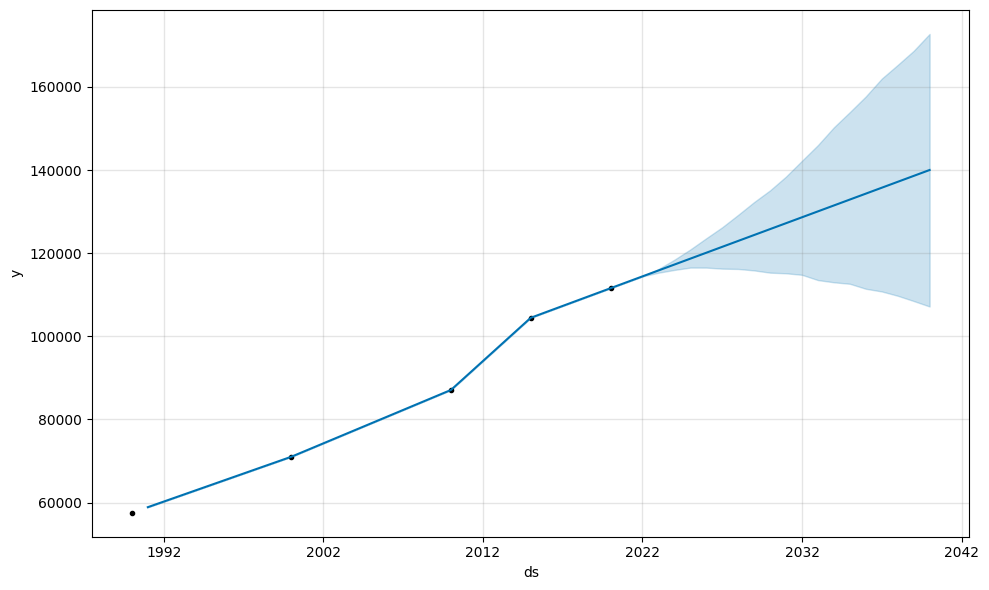

In [7]:
# Cell: ML Predictions with Prophet

def create_prophet_predictions(conn, county_name, heating_type):
    # Get historical data
    query = f"""
    SELECT Year, {heating_type}
    FROM energy_consumption 
    WHERE County = ?
    ORDER BY Year
    """
    df = pd.read_sql_query(query, conn, params=[county_name])
    
    # Prepare data for Prophet
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['Year'].astype(str)),
        'y': df[heating_type]
    })
    
    # Create and train model
    model = Prophet(
        yearly_seasonality=False,
        growth='linear',
        changepoint_prior_scale=0.5
    )
    model.fit(prophet_df)
    
    # Create future dates
    future_dates = pd.DataFrame({
        'ds': pd.date_range(
            start='2025-01-01', 
            end='2041-01-01',
            freq='5YE'
        )
    })
    
    # Generate predictions``
    forecast = model.predict(future_dates)
    
    # Create prediction DataFrame
    predictions = pd.DataFrame({
        'County': county_name,
        'Year': forecast['ds'].dt.year,
        heating_type: forecast['yhat'].astype(int)
    })
    
    return predictions, model

# Usage
county_name = 'Guilford County'
heating_type = 'heated_by_electricity'

# Generate predictions
predictions, model = create_prophet_predictions(conn, county_name, heating_type)

# Print results
print(f"\nProphet Predictions for {county_name}:")
print(predictions)

# Get historical data for comparison
historical = get_county_data(conn, county_name)
print(f"\nHistorical Data for {county_name}:")
print(historical[['Year', heating_type]])

# Plot results
fig = model.plot(model.predict(pd.DataFrame({
    'ds': pd.date_range(start='1990-01-01', end='2040-01-01', freq='YE')
})))
plt.show()

In [ ]:
#Generate predictions for all counties and heating types and store in database
def generate_and_store_predictions(conn):
    
    # Get all counties
    counties = pd.read_sql_query("SELECT DISTINCT County FROM energy_consumption", conn)
    
    # Get all heating types (excluding County and Year columns)
    heating_types = [col for col in pd.read_sql_query("SELECT * FROM energy_consumption LIMIT 1", conn).columns 
                    if col not in ['County', 'Year']]
    
    # Create predictions table if it doesn't exist
    create_predictions_table = """
    CREATE TABLE IF NOT EXISTS energy_predictions (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    )
    """
    conn.execute(create_predictions_table)
    
    # Generate predictions for each county and heating type
    all_predictions = []
    
    for _, county_row in counties.iterrows():
        county = county_row['County']
        print(f"Generating predictions for {county}...")
        
        county_predictions = {}
        for heating_type in heating_types:
            try:
                predictions, _ = create_prophet_predictions(conn, county, heating_type)
                county_predictions[heating_type] = predictions[heating_type].values
            except Exception as e:
                print(f"Error generating predictions for {county}, {heating_type}: {e}")
                county_predictions[heating_type] = None
        
        # Combine predictions for all heating types
        for year_idx, year in enumerate(range(2025, 2041, 5)):
            prediction_row = {
                'County': county,
                'Year': year
            }
            for heating_type in heating_types:
                if county_predictions[heating_type] is not None:
                    prediction_row[heating_type] = int(county_predictions[heating_type][year_idx])
                else:
                    prediction_row[heating_type] = 0
            
            all_predictions.append(prediction_row)
    
    # Convert to DataFrame and store in database
    predictions_df = pd.DataFrame(all_predictions)
    predictions_df.to_sql('energy_predictions', conn, if_exists='replace', index=False)
    
    print("Predictions generated and stored in database.")
    return predictions_df

# Generate and store predictions
predictions_df = generate_and_store_predictions(conn)

# Display sample of predictions
print("\nSample of generated predictions:")
print(predictions_df.head())

# Verify data in database
print("\nVerifying data in database:")
print(pd.read_sql_query("SELECT * FROM energy_predictions LIMIT 5", conn))

In [5]:
# Cell: Combine Historical and Predicted Data

def combine_historical_and_predictions(conn, output_file="nc_energy_combined.csv"):
    """Combine historical data and predictions into a single CSV file"""
    
    # Get historical data
    historical = pd.read_sql_query("""
        SELECT County, Year,
               heated_by_electricity,
               heated_by_gas,
               heated_by_fuel_oil,
               heated_by_other,
               no_heating,
               heated_by_lp_gas
        FROM energy_consumption
        ORDER BY County, Year
    """, conn)
    
    # Get predictions
    predictions = pd.read_sql_query("""
        SELECT County, Year,
               heated_by_electricity,
               heated_by_gas,
               heated_by_fuel_oil,
               heated_by_other,
               no_heating,
               heated_by_lp_gas
        FROM energy_predictions
        ORDER BY County, Year
    """, conn)
    
    # Combine datasets
    combined_data = pd.concat([historical, predictions], axis=0)
    
    # Sort by county and year
    combined_data = combined_data.sort_values(['County', 'Year'])
    
    # Save to CSV
    combined_data.to_csv(output_file, index=False)
    
    print(f"Combined data saved to {output_file}")
    print("\nSample of combined data:")
    print(combined_data.head(10))
    
    # Display some statistics
    print("\nYear range in combined dataset:")
    print(f"Earliest year: {combined_data['Year'].min()}")
    print(f"Latest year: {combined_data['Year'].max()}")
    print(f"\nTotal number of counties: {len(combined_data['County'].unique())}")
    print(f"Total number of records: {len(combined_data)}")

# Execute the combination
combine_historical_and_predictions(conn)

Combined data saved to nc_energy_combined.csv

Sample of combined data:
             County  Year  heated_by_electricity  heated_by_gas  \
0   Alamance County  1990                  12543          15946   
1   Alamance County  2000                  16783          24211   
2   Alamance County  2010                  23032          26390   
3   Alamance County  2015                  26576          26122   
4   Alamance County  2020                  32290          26842   
0   Alamance County  2025                  39146          27705   
1   Alamance County  2030                  44860          28425   
2   Alamance County  2035                  50574          29145   
3   Alamance County  2040                  56291          29866   
5  Alexander County  1990                   4095             20   

   heated_by_fuel_oil  heated_by_other  no_heating  heated_by_lp_gas  
0                7552             2541          64              4006  
1                2996             1005          